## PCA + LDA Image Classifier ##

### Images Splitter ###
only run once unless there are new images for datasets

In [1]:
#Split the images into train and test datasets

from pathlib import Path
import shutil
import random

# =========================
# CONFIG
# =========================
SOURCE_DIR = Path("./Images/Processed/P")   # your current dataset root
OUTPUT_DIR = Path("./datasets")      # new output folder
TRAIN_COUNT = 10
MIN_TEST_COUNT = 2

# allowed image extensions
IMAGE_EXTS = {".jpg", ".jpeg"}

# set seed for reproducibility
random.seed(42)


def is_image_file(path: Path) -> bool:
    return path.is_file() and path.suffix.lower() in IMAGE_EXTS


def safe_folder_name(name: str) -> str:
    # convert spaces to underscores for cleaner filenames
    return name.strip().replace(" ", "_")


def main():
    if not SOURCE_DIR.exists():
        raise FileNotFoundError(f"Source directory not found: {SOURCE_DIR}")

    # create output structure
    train_root = OUTPUT_DIR / "train"
    test_root = OUTPUT_DIR / "test"
    train_root.mkdir(parents=True, exist_ok=True)
    test_root.mkdir(parents=True, exist_ok=True)

    person_dirs = [p for p in SOURCE_DIR.iterdir() if p.is_dir()]

    if not person_dirs:
        print("No person folders found.")
        return

    for person_dir in sorted(person_dirs):
        person_name = safe_folder_name(person_dir.name)

        images = [p for p in person_dir.iterdir() if is_image_file(p)]
        images.sort()

        if len(images) == 0:
            print(f"[SKIP] {person_dir.name}: no images found")
            continue

        random.shuffle(images)
        total = len(images)

        # Decide split
        if total >= TRAIN_COUNT + MIN_TEST_COUNT:
            train_imgs = images[:TRAIN_COUNT]
            test_imgs = images[TRAIN_COUNT:]
        elif total >= MIN_TEST_COUNT + 1:
            # keep at least 2 test if possible, rest train
            test_imgs = images[-MIN_TEST_COUNT:]
            train_imgs = images[:-MIN_TEST_COUNT]
        else:
            # too few images, put all into train
            train_imgs = images
            test_imgs = []

        # create class folders
        train_person_dir = train_root / person_name
        test_person_dir = test_root / person_name
        train_person_dir.mkdir(parents=True, exist_ok=True)
        test_person_dir.mkdir(parents=True, exist_ok=True)

        # copy + rename train images
        for i, img_path in enumerate(train_imgs, start=1):
            new_name = f"{person_name}_{i:03d}{img_path.suffix.lower()}"
            shutil.copy2(img_path, train_person_dir / new_name)

        # copy + rename test images
        for j, img_path in enumerate(test_imgs, start=1):
            new_name = f"{person_name}_test_{j:03d}{img_path.suffix.lower()}"
            shutil.copy2(img_path, test_person_dir / new_name)

        print(
            f"[DONE] {person_dir.name} -> "
            f"train: {len(train_imgs)}, test: {len(test_imgs)}"
        )

    print(f"\nFinished. Output saved to: {OUTPUT_DIR.resolve()}")


if __name__ == "__main__":
    main()

[DONE] P_Fathiah -> train: 6, test: 2
[DONE] P_Fazil -> train: 10, test: 2
[DONE] P_Jasper -> train: 10, test: 6
[DONE] P_Joe -> train: 10, test: 4
[DONE] P_Mikail -> train: 10, test: 2
[DONE] P_Roy -> train: 9, test: 2
[DONE] P_Syarah -> train: 10, test: 5

Finished. Output saved to: /home/fazil/Documents/Univ/IE4228/datasets


In [1]:
"""
1. load images

2. assign labels from folder names

3. flatten each image into a vector

4. apply PCA on train

5. apply LDA on PCA output

6. evaluate on test

7. save model
"""

'\n1. load images\n\n2. assign labels from folder names\n\n3. flatten each image into a vector\n\n4. apply PCA on train\n\n5. apply LDA on PCA output\n\n6. evaluate on test\n\n7. save model\n'

In [2]:
import os
import cv2
import numpy as np

IMG_SIZE = (90, 90)   # recommended in assignment


def load_dataset(dataset_path):
    
    X = []
    y = []
    
    for person_name in sorted(os.listdir(dataset_path)):
        
        person_dir = os.path.join(dataset_path, person_name)
        
        if not os.path.isdir(person_dir):
            continue
        
        for file in os.listdir(person_dir):
            
            img_path = os.path.join(person_dir, file)
            
            # read image
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            
            if img is None:
                continue
            
            # normalize
            img = img.astype(np.float32) / 255.0
            
            # flatten
            img_vector = img.flatten()
            
            X.append(img_vector)
            y.append(person_name)
    
    X = np.array(X)
    y = np.array(y)
    
    return X, y



In [3]:
# =========================
# load train and test
# =========================

X_train, y_train = load_dataset("./datasets/train")
X_test, y_test = load_dataset("./datasets/test")

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (65, 8100)
Test shape: (23, 8100)


Mean face shape: (8100,)


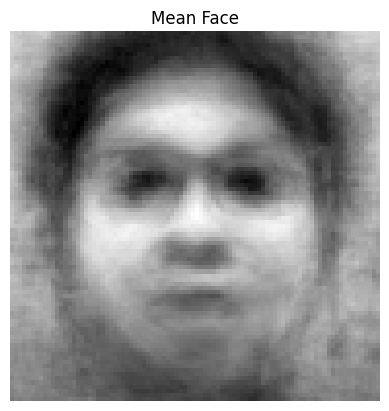

In [4]:
import matplotlib.pyplot as plt

mean_face = np.mean(X_train, axis=0)
print("Mean face shape:", mean_face.shape)

# visualize mean face of train set

mean_img = mean_face.reshape(90, 90)

plt.imshow(mean_img, cmap="gray")
plt.title("Mean Face")
plt.axis("off")
plt.show()

X_train_centered = X_train - mean_face
X_test_centered = X_test - mean_face

In [ ]:
#we compute X.T @ X instead of X @ X.T to avoid huge computations since we have thousands of features (8100)
XtX = X_train_centered @ X_train_centered.T
XtX.shape

(65, 65)

In [7]:
eigenvalues, eigenvectors = np.linalg.eig(XtX)

# sort eigenvalues and eigenvectors in descending order
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors_small = eigenvectors[:, idx]

In [31]:
# converting eigenvetors of X.T @ X to eigenvectors of X @ X.T
eigenvectors_large = X_train_centered.T @ eigenvectors_small

# normalize eigenvectors
eigenvectors_large = eigenvectors_large / np.linalg.norm(eigenvectors_large, axis=0)

eigenvectors_large.shape

(8100, 65)

In [ ]:
from sklearn.metrics import accuracy_score

k_values = [5,10,15,20,30,40,50,100,200,400,800,1600,3200,6400]
accuracies = []

for k in k_values:

    U = eigenvectors_large[:, :k]

    W_train = X_train_centered @ U
    W_test = (X_test - mean_face) @ U

    predictions = []

    for w in W_test:
        distances = np.linalg.norm(W_train - w, axis=1)
        idx = np.argmin(distances)
        predictions.append(y_train[idx])

    acc = accuracy_score(y_test, predictions)
    accuracies.append(acc)

print(accuracies)

[0.5217391304347826, 0.5217391304347826, 0.4782608695652174, 0.5217391304347826, 0.5217391304347826, 0.5217391304347826, 0.5217391304347826]


In [ ]:
# implement dimensionality reduction by selecting top k eigenvectors out of 8100 features
k = 50  # number of principal components to keep
eigenvectors_reduced = eigenvectors_large[:, :k]

eigenvectors_reduced.shape


(8100, 50)

In [29]:
# Reduce dimensionality of train sets
X_train_reduced = X_train_centered @ eigenvectors_reduced
X_train_reduced.shape

(65, 50)